In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from le_fun import le_derivatives, find_zero, le_analytical
from scipy.integrate import solve_ivp

In [2]:
# Pretty colours for plotting
colours = cm.inferno(np.linspace(0, 0.9, 20))

t_span = [1e-10, 40] # xi = 0 can create problems, so I'll use a small number
y0 = (1 + 0j,0 + 0j) # Using complex numbers helps solve_ivp understand certain solutions
find_zero.terminal = True

# Computing for one value of $n$

I choose $n=1$ to start off with. I obtain the numerical solution for $\theta(\xi_1)=0$ and then compare it to the analytical solution.

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/optimize/_zeros_py.py:798: ComplexWarning: Casting complex values to real discards the imaginary part
  r = _zeros._brentq(f, a, b, xtol, rtol, maxiter, args, full_output, disp)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


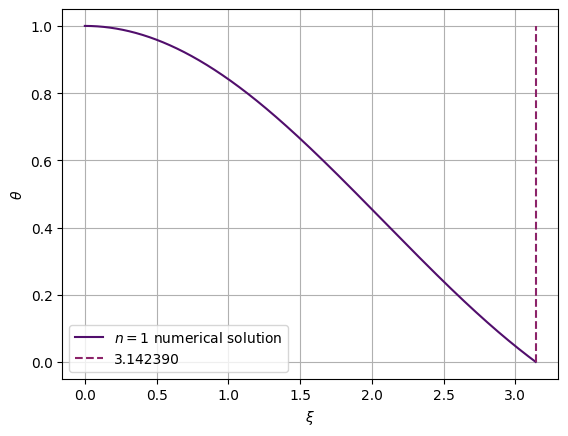

In [3]:
# for n = 1
le_1 = solve_ivp(le_derivatives, 
                 t_span=t_span, 
                 y0=y0, 
                 dense_output=True, 
                 args=(1,), 
                 events=find_zero)

# Generate a graph
t_1 = np.linspace(0, min(le_1.t_events[0][0], 10), 1000)
plt.plot(t_1, le_1.sol(t_1)[0], c=colours[5], label=r'$n=1$ numerical solution')
plt.vlines(le_1.t_events[0], ymin=0, ymax=1, linestyles='--', colors=colours[8], label=r'%f' % le_1.t_events[0][0])
plt.xlabel(r'$\xi$')
plt.ylabel(r'$\theta$')
plt.legend(loc='lower left')
plt.grid()
plt.show()

/Users/galacticmilk/Desktop/Michael's folder/[UNI]/[SURP]/2026/lane_emden/le_fun.py:75: RuntimeWarning: invalid value encountered in divide
  return np.sin(xi) / xi


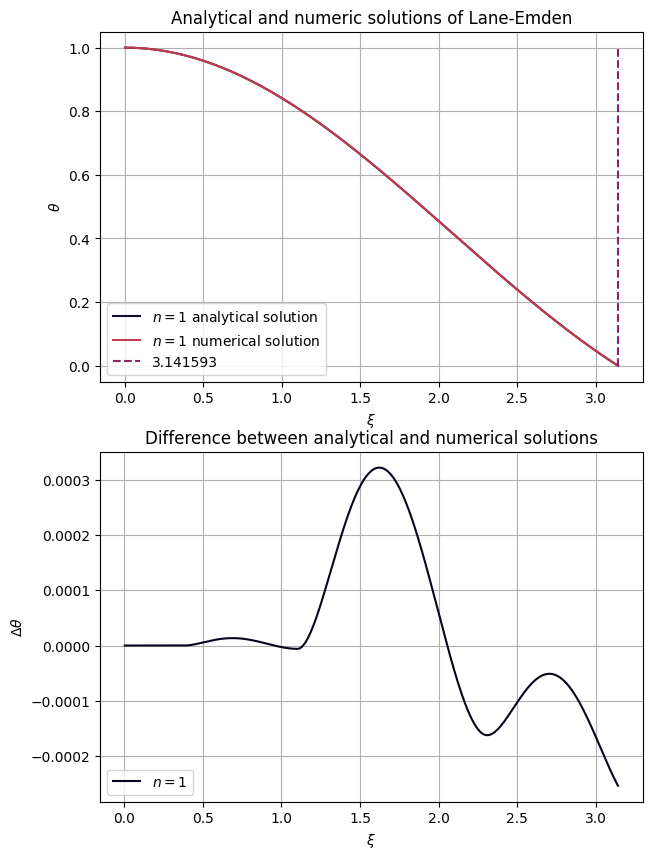

In [4]:
# Graphing this with the time steps used previously,
fig, ax = plt.subplots(2, 1, dpi=100, figsize=(7, 10))

ax[0].plot(t_1, le_analytical(t_1, 1), c=colours[2], label=r'$n=1$ analytical solution')
ax[0].plot(t_1, le_1.sol(t_1)[0], c=colours[11], label=r'$n=1$ numerical solution')
ax[0].vlines(np.pi, ymin=0, ymax=1, linestyle='--', colors=colours[8], label=f'{np.pi:1f}')
ax[0].set_xlabel(r'$\xi$')
ax[0].set_ylabel(r'$\theta$')
ax[0].set_title('Analytical and numeric solutions of Lane-Emden')
ax[0].grid()
ax[0].legend(loc='lower left')

ax[1].set_title('Difference between analytical and numerical solutions')
ax[1].plot(t_1, le_analytical(t_1, 1) - le_1.sol(t_1)[0], c=colours[1], label=r'$n=1$')
ax[1].set_xlabel(r'$\xi$')
ax[1].set_ylabel(r'$\Delta\theta$')
ax[1].legend(loc='lower left')
ax[1].grid()
plt.show()

# Plotting numerical solutions to many values of $n$

Now I want to graph solutions for $\theta(\xi)$ for any value of $n$. I'll compute it for a finite number of $n$ values, and compare it to tables of known values of $\xi_1$ for each $n$.

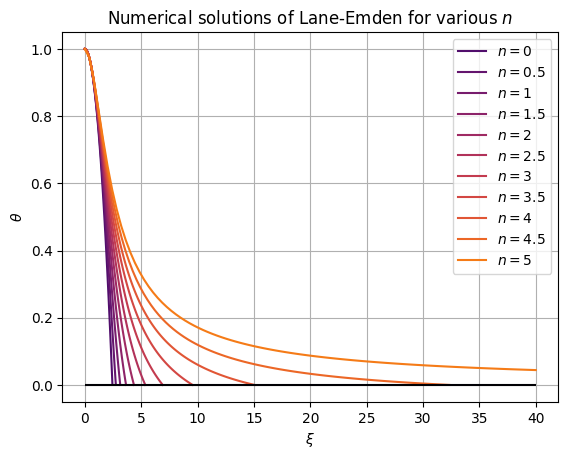

In [5]:
# The values of xi_1 for each of these are tabulated, so I'll compare the obtained solutions here to what the actual values are.
n_list = [0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5]
xi_1_list = {'real': [2.4494,
             3.7528,
             np.pi,
             3.65375,
             4.35287,
             5.35528,
             6.89685,
             9.53581,
             14.97155,
             31.83646,
             -1]} # I'll use -1 to represent the fact that xi_1 is infinite for n = 5

num_xi_1 = [-1 for _ in n_list] # Setting up the list to store numerical solutions to theta = 0

for i in range(len(n_list)):
    sol = solve_ivp(le_derivatives, 
                    t_span=t_span, 
                    y0=y0, 
                    args=(n_list[i],), 
                    events=find_zero, 
                    dense_output=True)
    if sol.t_events[0].size != 0:
        t_lim = sol.t_events[0][0]
        num_xi_1[i] = t_lim
        # print(r'n = %.1f: Difference = %f' % (n_list[i], abs(xi_1_list[i]-num_xi_1[i])))
    else:
        t_lim = t_span[-1]
    t = np.linspace(t_span[0], t_lim, 100)
    plt.plot(t, sol.sol(t)[0], c=colours[i+5], label=rf'$n={n_list[i]}$')

plt.hlines(0, xmin=t_span[0], xmax=t_span[-1], colors=colours[0])
plt.legend()
plt.title(r'Numerical solutions of Lane-Emden for various $n$')
plt.xlabel(r'$\xi$')
plt.ylabel(r'$\theta$')
plt.grid()
plt.show()

# Plotting the values of $\xi_1$

I'd like to compare the values of each $\xi_1$ obtained through our numerical integration and what the known values are, ideally on a bar chart. Then, maybe we could try to plot how $\xi_1$ evolves over many values of $n$.

/var/folders/pq/cnfsm69s0f721lh2sr1bvzpw0000gn/T/ipykernel_86617/3364956802.py:23: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[1].scatter(x + offset,


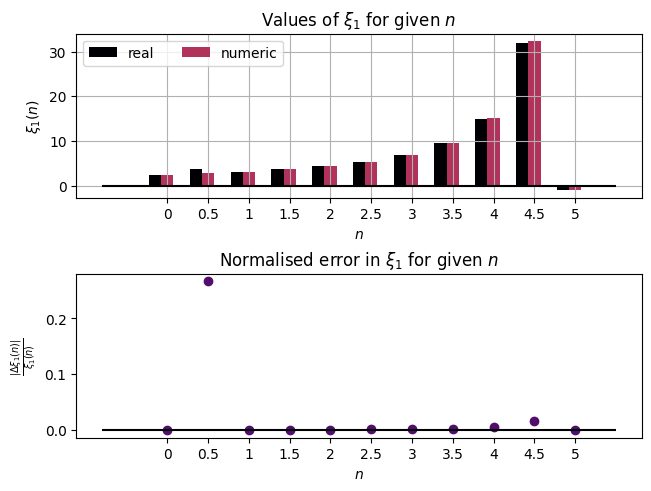

In [6]:
fig, ax = plt.subplots(2, 1,layout='constrained', dpi=100)

xi_1_list['numeric'] = num_xi_1

x = np.arange(len(n_list))
w = 0.3 # bar widths
multiplier = 0

for attribute, measurement in xi_1_list.items():
    offset = w * multiplier
    rects = ax[0].bar(x + offset, measurement, w, label=rf'{attribute}', color=colours[multiplier* 10])
    multiplier += 1

ax[0].hlines(0, xmin=-w-1, xmax=len(n_list)+w, colors=colours[0])
ax[0].grid()
ax[0].legend()
ax[0].set_ylabel(r'$\xi_1(n)$')
ax[0].set_title(r'Values of $\xi_1$ for given $n$')
ax[0].set_xticks(x + w, n_list)
ax[0].set_xlabel(r'$n$')
ax[0].legend(loc='upper left', ncols=3)

ax[1].scatter(x + offset, 
              abs((np.array(xi_1_list['real']) - np.array(xi_1_list['numeric']))/np.array(xi_1_list['real'])),
              c=colours[5])
ax[1].hlines(0, xmin=-w-1, xmax=len(n_list)+w, colors=colours[0])
# ax[1].legend()
ax[1].set_ylabel(r'$\frac{|\Delta\xi_1(n)|}{\xi_1(n)}$')
ax[1].set_title(r'Normalised error in $\xi_1$ for given $n$')
ax[1].set_xticks(x + w, n_list)
ax[1].set_xlabel(r'$n$')

plt.show()

The simulated values for $\xi_1$ are pretty close to the actual solutions, maybe except for $n=0.5$ and $n=4.5$, which have larger errors. I'll now plot $\xi_1$ for continuous $n$ using numerical simulations:

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/optimize/_zeros_py.py:798: ComplexWarning: Casting complex values to real discards the imaginary part
  r = _zeros._brentq(f, a, b, xtol, rtol, maxiter, args, full_output, disp)
/var/folders/pq/cnfsm69s0f721lh2sr1bvzpw0000gn/T/ipykernel_86617/3645927196.py:16: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(n_list_cont[i],


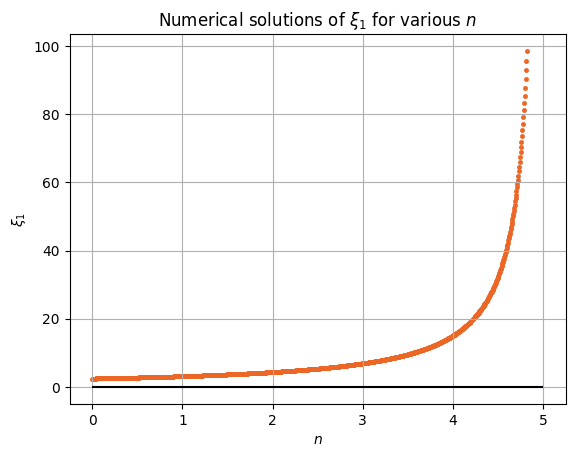

In [7]:
accuracy = 1000

big_time = [1e-10, 100]

n_list_cont = np.linspace(0, 5, accuracy)

for i in range(len(n_list_cont)):
    sol = solve_ivp(le_derivatives, 
                    t_span=big_time, 
                    y0=y0, 
                    args=(n_list_cont[i],), 
                    events=find_zero, 
                    dense_output=True)
    if sol.t_events[0].size != 0:
        t_lim = sol.t_events[0][0]
        plt.scatter(n_list_cont[i], 
                    t_lim, 
                    c=colours[14], 
                    # c=colours[int(i//(accuracy/20))], 
                    linewidths=0.5, 
                    marker='.')
    else:
        pass

plt.hlines(0, xmin=0, xmax=5, colors=colours[0])
plt.title(r'Numerical solutions of $\xi_1$ for various $n$')
plt.xlabel(r'$n$')
plt.ylabel(r'$\xi_1$')
plt.grid()
plt.show()

# What about $n<0$?

I'm curious about the behaviour of the ODE if I set $n<0$

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


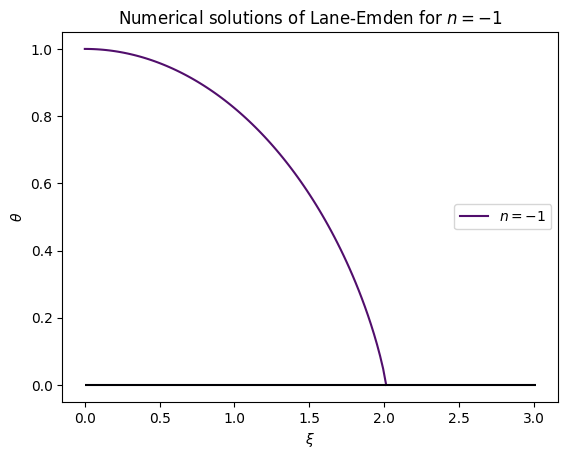

In [8]:
sol = solve_ivp(le_derivatives, 
                t_span=t_span, 
                y0=y0, 
                args=(-1,),  # Here is where I set n = -1
                events=find_zero, 
                dense_output=True)
if sol.t_events[0].size != 0:
    t_lim = sol.t_events[0][0]
else:
    t_lim = t_span[-1]
t = np.linspace(t_span[0], t_lim, 100)
plt.plot(t, sol.sol(t)[0], c=colours[5], label=rf'$n=-1$')

plt.hlines(0, xmin=t_span[0], xmax=t_lim + 1, colors=colours[0])
plt.legend(loc='center right')
plt.title(r'Numerical solutions of Lane-Emden for $n=-1$')
plt.xlabel(r'$\xi$')
plt.ylabel(r'$\theta$')
plt.show()

But if I try for $n<1$ I get some weird interactions

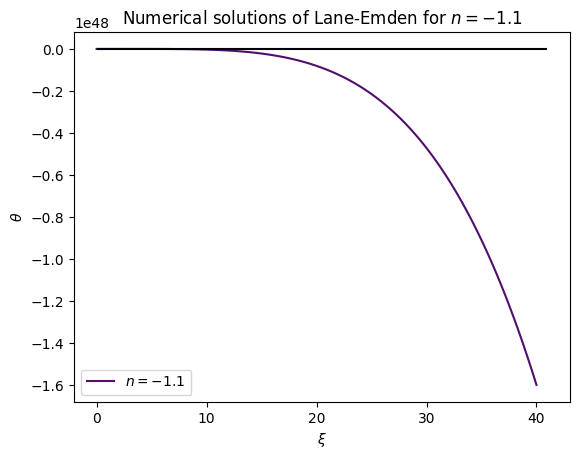

In [9]:
sol = solve_ivp(le_derivatives, 
                t_span=t_span, 
                y0=y0, 
                args=(-1.1,),
                events=find_zero, 
                dense_output=True)
if sol.t_events[0].size != 0:
    t_lim = sol.t_events[0][0]
else:
    t_lim = t_span[-1]
t = np.linspace(t_span[0], t_lim, 100)
plt.plot(t, sol.sol(t)[0], c=colours[5], label=rf'$n=-1.1$')

plt.hlines(0, xmin=t_span[0], xmax=t_lim + 1, colors=colours[0])
plt.legend(loc='lower left')
plt.title(r'Numerical solutions of Lane-Emden for $n=-1.1$')
plt.xlabel(r'$\xi$')
plt.ylabel(r'$\theta$')
plt.show()

# ?
No clue what's happening here

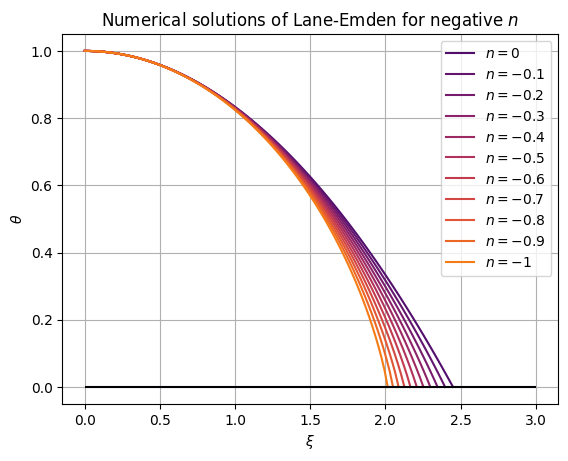

In [10]:
n_neg_list = [0, -0.1, -0.2, -0.3, -0.4, -0.5, -0.6, -0.7, -0.8, -0.9, -1]

for i in range(len(n_neg_list)):
    sol = solve_ivp(le_derivatives, 
                    t_span=t_span, 
                    y0=y0, 
                    args=(n_neg_list[i],), 
                    events=find_zero, 
                    dense_output=True)
    if sol.t_events[0].size != 0:
        t_lim = sol.t_events[0][0]
    else:
        t_lim = t_span[-1]
    t = np.linspace(t_span[0], t_lim, 100)
    plt.plot(t, sol.sol(t)[0], c=colours[i+5], label=rf'$n={n_neg_list[i]}$')

plt.hlines(0, xmin=t_span[0], xmax=3, colors=colours[0])
plt.legend()
plt.title(r'Numerical solutions of Lane-Emden for negative $n$')
plt.xlabel(r'$\xi$')
plt.ylabel(r'$\theta$')
plt.grid()
plt.show()

/Users/galacticmilk/Desktop/Michael's folder/[UNI]/[SURP]/2026/lane_emden/le_fun.py:96: RuntimeWarning: invalid value encountered in divide
  w = ~np.isnan(rho/rhoprev) # necessary because the last value of rho is zero.
/Users/galacticmilk/Desktop/Michael's folder/[UNI]/[SURP]/2026/lane_emden/le_fun.py:118: RuntimeWarning: invalid value encountered in divide
  P = P*Egrav/TwoEtherm ## enforce virial equilibrium: |E_grav| = 2 E_therm


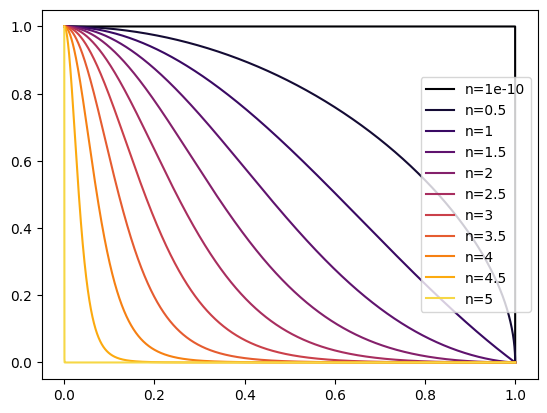

In [13]:
from le_fun import getpoly

n_list = [1e-10, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5]
colours2 = cm.inferno(np.linspace(0, 0.9, len(n_list)))

for i, n in enumerate(n_list):
    r, rho, m, P = getpoly(n)
    theta = rho/rho[0]
    plt.plot(r, theta, label=f"n={n}", color=colours2[i])
plt.legend()
plt.show()

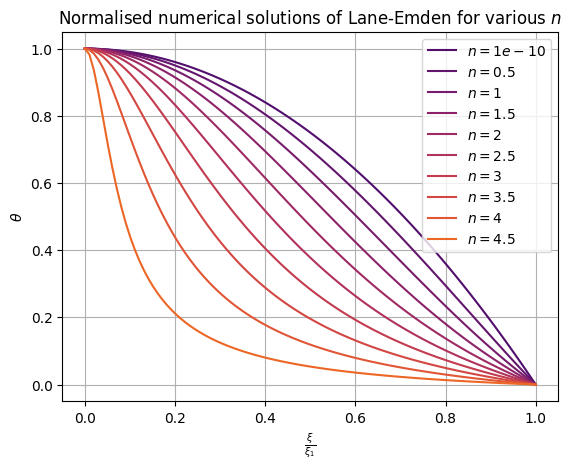

In [18]:
norm_n_list = [0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5]

# norm_num_xi_1 = [-1 for _ in n_list] # Setting up the list to store numerical solutions to theta = 0

for i in range(len(norm_n_list)):
    sol = solve_ivp(le_derivatives, 
                    t_span=t_span, 
                    y0=y0, 
                    args=(norm_n_list[i],), 
                    events=find_zero, 
                    dense_output=True)
    if sol.t_events[0].size != 0:
        t_lim = sol.t_events[0][0]
        # print(r'n = %.1f: Difference = %f' % (n_list[i], abs(xi_1_list[i]-num_xi_1[i])))
    else:
        t_lim = t_span[-1]
    t = np.linspace(t_span[0], t_lim, 100)
    plt.plot(t/t_lim, sol.sol(t)[0], c=colours[i+5], label=rf'$n={n_list[i]}$')

# plt.hlines(0, xmin=t_span[0], xmax=t_span[-1], colors=colours[0])
plt.legend()
plt.title(r'Normalised numerical solutions of Lane-Emden for various $n$')
plt.xlabel(r'$\frac{\xi}{\xi_1}$')
plt.ylabel(r'$\theta$')
plt.grid()
plt.show()